# Step 1: Import Required Libraries
Import all necessary libraries for data analysis and modeling. We use pandas for data manipulation, numpy for numerical operations, matplotlib for visualization, scikit-learn for preprocessing and metrics, and XGBoost for the regression model. Warnings are suppressed to keep output clean.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
import xgboost as xgb
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

# Step 2: Load the Ames Housing Dataset
Read the training and test CSV files. The training set has 1460 houses with features and sale prices, while the test set has 1459 houses with features only (we need to predict prices). Display the shapes and first few rows to verify data loaded correctly.

In [7]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print('Training data:', train_df.shape)
print('Test data:', test_df.shape)
train_df.head()

Training data: (1460, 81)
Test data: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# Step 3: Analyze Target Variable
Visualize the distribution of SalePrice to check if transformation is needed. House prices are typically right-skewed (many affordable houses, few expensive ones). We plot both original and log-transformed distributions. Log transformation (log1p) makes the distribution more normal, which helps the model perform better.

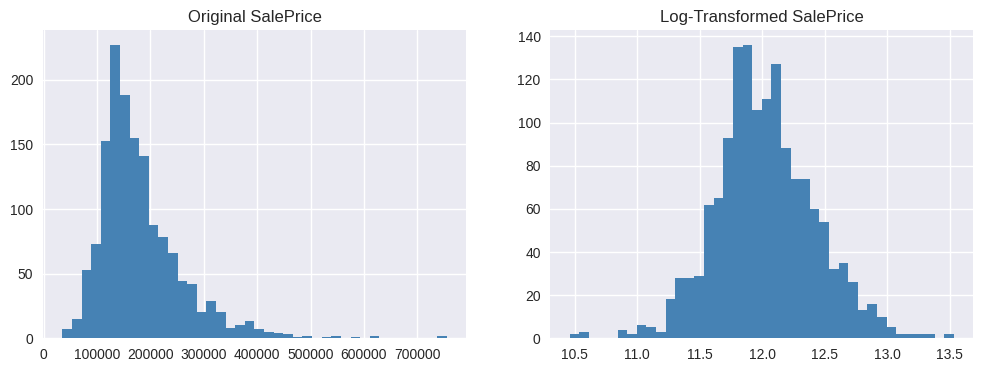

Skewness before: 1.88
Skewness after: 0.12


In [53]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(train_df['SalePrice'], bins=40, color='steelblue')
ax[0].set_title('Original SalePrice')

ax[1].hist(np.log1p(train_df['SalePrice']), bins=40, color='steelblue')
ax[1].set_title('Log-Transformed SalePrice')

plt.show()

print('Skewness before:', round(train_df['SalePrice'].skew(), 2))
print('Skewness after:', round(np.log1p(train_df['SalePrice']).skew(), 2))

# Step 4: Combine Train and Test Data
Extract the target variable (log-transformed SalePrice) and combine training and test datasets. This ensures we apply the same preprocessing (missing value imputation, encoding) to both datasets consistently. We save the number of training rows to split them back later.

In [40]:
num_train = train_df.shape[0]
target = np.log1p(train_df['SalePrice'])

combined_data = pd.concat([train_df.drop('SalePrice', axis=1), test_df], axis=0, ignore_index=True)

print('Combined data:', combined_data.shape)
print('Missing values:', combined_data.isnull().sum().sum())

Combined data: (2919, 80)
Missing values: 15707


# Step 5: Impute Missing Values
Handle missing values using domain knowledge. For features like PoolQC or Alley, NaN means "does not exist" so we fill with 'None'. For area/count features like GarageArea, we fill with 0. LotFrontage is filled with neighborhood median (houses in same area have similar frontage). Remaining categorical columns get the mode value.

In [41]:
none_features = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
                 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
                 'MasVnrType']
for col in none_features:
    combined_data[col] = combined_data[col].fillna('None')

zero_features = ['GarageYrBlt', 'GarageArea', 'GarageCars', 'MasVnrArea',
                 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
                 'BsmtFullBath', 'BsmtHalfBath']
for col in zero_features:
    combined_data[col] = combined_data[col].fillna(0)

combined_data['LotFrontage'] = combined_data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median()))

mode_features = ['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd',
                 'Electrical', 'KitchenQual', 'Functional', 'SaleType']
for col in mode_features:
    combined_data[col] = combined_data[col].fillna(combined_data[col].mode()[0])

print('Remaining missing values:', combined_data.isnull().sum().sum())

Remaining missing values: 0


# Step 6: Convert MSSubClass Type
Convert MSSubClass from integer to string. Although it looks like a number (20, 30, 40...), it's actually a category code representing different dwelling types. Converting to string prevents the model from treating it as a numerical value where higher numbers mean "more" of something.

In [42]:
combined_data['MSSubClass'] = combined_data['MSSubClass'].astype(str)

# Step 7: Encode Ordinal Features
Map ordinal categorical variables to numerical scores. Quality features (ExterQual, KitchenQual, etc.) have natural ordering: Poor < Fair < Typical < Good < Excellent. We map these to 0-5 so the model can use this ordering information. Other ordinal features like BsmtExposure and GarageFinish get their own custom mappings.

In [43]:
quality_mapping = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
quality_features = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
                    'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']

for col in quality_features:
    combined_data[col] = combined_data[col].map(quality_mapping)

combined_data['BsmtExposure'] = combined_data['BsmtExposure'].map({'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4})
combined_data['BsmtFinType1'] = combined_data['BsmtFinType1'].map({'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6})
combined_data['BsmtFinType2'] = combined_data['BsmtFinType2'].map({'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6})
combined_data['GarageFinish'] = combined_data['GarageFinish'].map({'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3})

# Step 8: Identify Categorical Columns
Separate remaining columns into categorical and numerical types. After ordinal mapping, some categorical columns still need encoding (like Neighborhood, SaleType). We'll compare two encoding approaches: label encoding (converts categories to integers) vs one-hot encoding (creates binary columns for each category).

In [44]:
cat_cols = combined_data.select_dtypes(include=['object']).columns.tolist()
num_cols = combined_data.select_dtypes(include=['int64', 'float64']).columns.tolist()

print('Categorical columns:', len(cat_cols))
print('Numerical columns:', len(num_cols))

Categorical columns: 30
Numerical columns: 50


# Step 9: Apply Label Encoding
First approach: Label Encoding. Convert each categorical column to integers (0, 1, 2...). This is simple and creates fewer features, but may create artificial ordering where none exists. We create a copy of the data and store encoders in case we need to reverse the transformation later.

In [45]:
data_label = combined_data.copy()
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    data_label[col + '_enc'] = le.fit_transform(data_label[col])
    encoders[col] = le

feature_cols_label = num_cols + [col + '_enc' for col in cat_cols]
X_label = data_label[feature_cols_label]

print('Label encoded features:', X_label.shape)

Label encoded features: (2919, 80)


# Step 10: Train Model with Label Encoding
Split data into training (80%) and validation (20%) sets, then train XGBoost regressor. We use validation set to evaluate performance on unseen data. XGBoost parameters: 800 trees, learning rate 0.03, max depth 3. These prevent overfitting while capturing complex patterns. Calculate RMSE, MAE, and R² metrics.

In [46]:
X_train_lbl, X_val_lbl, y_train_lbl, y_val_lbl = train_test_split(
    X_label.iloc[:num_train], target, test_size=0.2, random_state=42)

model_label = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42
)
model_label.fit(X_train_lbl, y_train_lbl)

preds_label = model_label.predict(X_val_lbl)
rmse_label = np.sqrt(mean_squared_error(y_val_lbl, preds_label))
mae_label = mean_absolute_error(y_val_lbl, preds_label)
r2_label = r2_score(y_val_lbl, preds_label)

print(f'Label Encoding - RMSE: {rmse_label:.4f}, MAE: {mae_label:.4f}, R2: {r2_label:.4f}')

Label Encoding - RMSE: 0.1288, MAE: 0.0843, R2: 0.9111


# Step 11: Apply One-Hot Encoding
Second approach: One-Hot Encoding. Create binary columns for each category (e.g., Neighborhood_CollgCr, Neighborhood_Gilbert). This avoids artificial ordering but creates many more features. We use drop_first=True to avoid multicollinearity (dummy variable trap).

In [47]:
data_onehot = combined_data.copy()
data_encoded = pd.get_dummies(data_onehot, drop_first=True)

X_onehot = data_encoded

print('One-hot encoded features:', X_onehot.shape)

One-hot encoded features: (2919, 229)


# Step 12: Train Model with One-Hot Encoding
Split and train XGBoost with identical parameters as label encoding model. Using same random_state=42 ensures identical train/validation split for fair comparison. Only difference is the encoding method, so any performance difference is due to encoding choice.

In [48]:
X_train_oh, X_val_oh, y_train_oh, y_val_oh = train_test_split(
    X_onehot.iloc[:num_train], target, test_size=0.2, random_state=42)

model_onehot = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42
)
model_onehot.fit(X_train_oh, y_train_oh)

preds_onehot = model_onehot.predict(X_val_oh)
rmse_onehot = np.sqrt(mean_squared_error(y_val_oh, preds_onehot))
mae_onehot = mean_absolute_error(y_val_oh, preds_onehot)
r2_onehot = r2_score(y_val_oh, preds_onehot)

print(f'One-Hot Encoding - RMSE: {rmse_onehot:.4f}, MAE: {mae_onehot:.4f}, R2: {r2_onehot:.4f}')

One-Hot Encoding - RMSE: 0.1332, MAE: 0.0860, R2: 0.9049


# Step 13: Compare Encoding Methods
Compare RMSE scores from both approaches. Lower RMSE means better predictions. The winner is whichever encoding gives lower validation error. This tells us which encoding method works better for this specific dataset and model.

In [49]:
print('Label Encoding RMSE:', round(rmse_label, 4))
print('One-Hot Encoding RMSE:', round(rmse_onehot, 4))

if rmse_onehot < rmse_label:
    print('Better: One-Hot Encoding')
    winning_features = X_onehot
else:
    print('Better: Label Encoding')
    winning_features = X_label

Label Encoding RMSE: 0.1288
One-Hot Encoding RMSE: 0.1332
Better: Label Encoding


# Step 14: Feature Importance Plot
Visualize which features most influence predictions. XGBoost provides feature importance scores based on how much each feature reduces prediction error. We plot top 15 features to understand what drives house prices (typically location, quality, and size features).

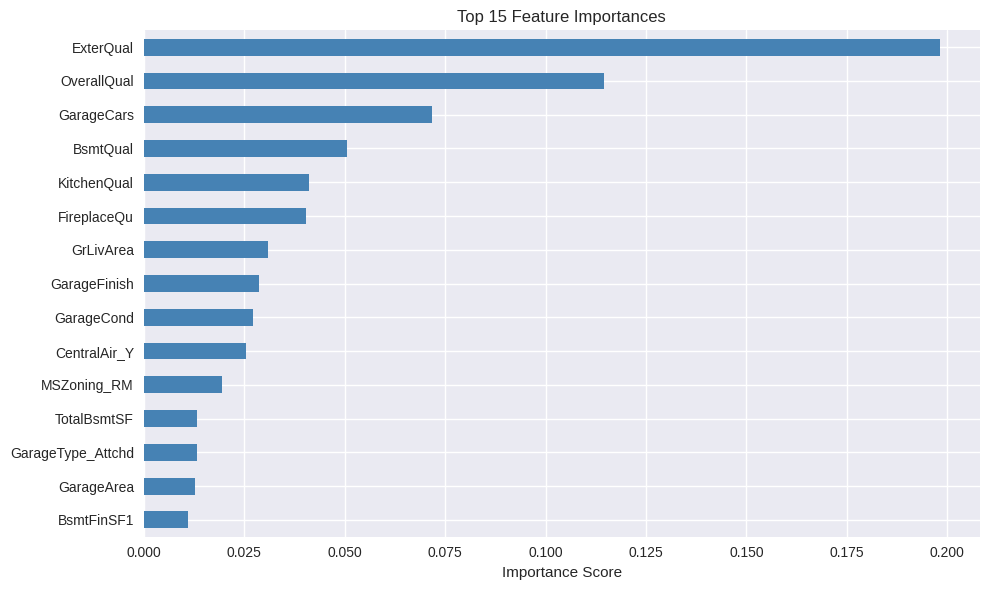

In [50]:
feat_imp = pd.Series(model_onehot.feature_importances_, index=X_onehot.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
feat_imp.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 15 Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Step 15: Train Final Model
Train final model on all training data (not just 80%) using the winning encoding method. More training data usually means better predictions. We use the same XGBoost parameters that performed well on validation set.

In [51]:
if rmse_onehot < rmse_label:
    X_final = X_onehot.iloc[:num_train]
    X_test = X_onehot.iloc[num_train:]
    print('Final model: One-Hot Encoding')
else:
    X_final = X_label.iloc[:num_train]
    X_test = X_label.iloc[num_train:]
    print('Final model: Label Encoding')

final_model = XGBRegressor(
    n_estimators=800, learning_rate=0.03, max_depth=3,
    subsample=0.7, colsample_bytree=0.7, random_state=42
).fit(X_final, target)

Final model: Label Encoding


# Step 16: Generate Predictions
Make predictions on test set and convert from log scale back to dollars using expm1 (inverse of log1p). Create submission DataFrame with Id and SalePrice columns, save to CSV for Kaggle submission. Display first few predictions to verify output format.

In [52]:
predictions = np.expm1(final_model.predict(X_test))

submission_df = pd.DataFrame({'Id': test_df['Id'], 'SalePrice': predictions})
submission_df.to_csv('submission.csv', index=False)

print('Submission file:', submission_df.shape)
submission_df.head()

Submission file: (1459, 2)


,Id,SalePrice
0,1461,123662.078125
1,1462,156467.859375
2,1463,183832.562500
3,1464,190515.593750
4,1465,186565.015625
